### EN3160 Assignment 1
#### Intensity Transformations and Neighborhood Filtering

**Name** : Upekshani T. S. <br>
**Index Number** : 230659H <br>

**GitHub:** [EN3160 Assignment 1](https://github.com/shalaniupekshani/EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering)

#### Question 1 – Intensity Transformation

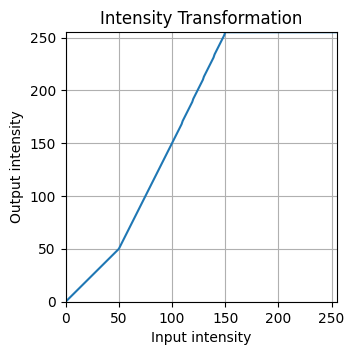

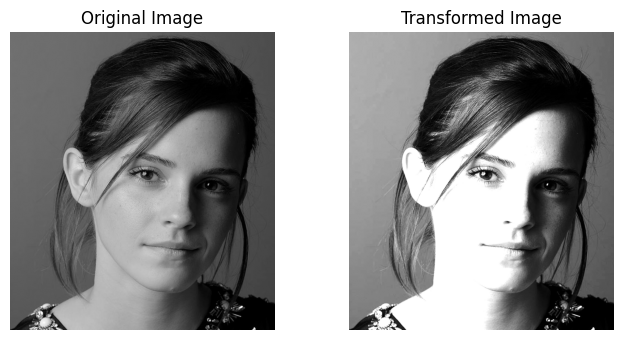

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transform = np.zeros(256, dtype=np.uint8)

    for i in range(len(breakpoints)-1):
        x1,y1=breakpoints[i]
        x2,y2=breakpoints[i+1]
        x=np.arange(x1,x2+1)
        y=np.linspace(y1,y2,len(x))
        transform[x]=y.astype(np.uint8)

    transformed_image=cv.LUT(im,transform)

    return transformed_image,transform
    
breakpoints=np.array([(0,0),(50,50),(100,150),(150,255),(255,255)])
im=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q1\emma.jpg',cv.IMREAD_GRAYSCALE)

transformed_image, transform = intensity_transform(im,breakpoints)   


# Intensity transformation plot
plt.figure(figsize=(3.5, 3.5))

plt.plot(np.arange(256), transform)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()


# Display images
plt.figure(figsize=(7, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed_image, cmap='gray')
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

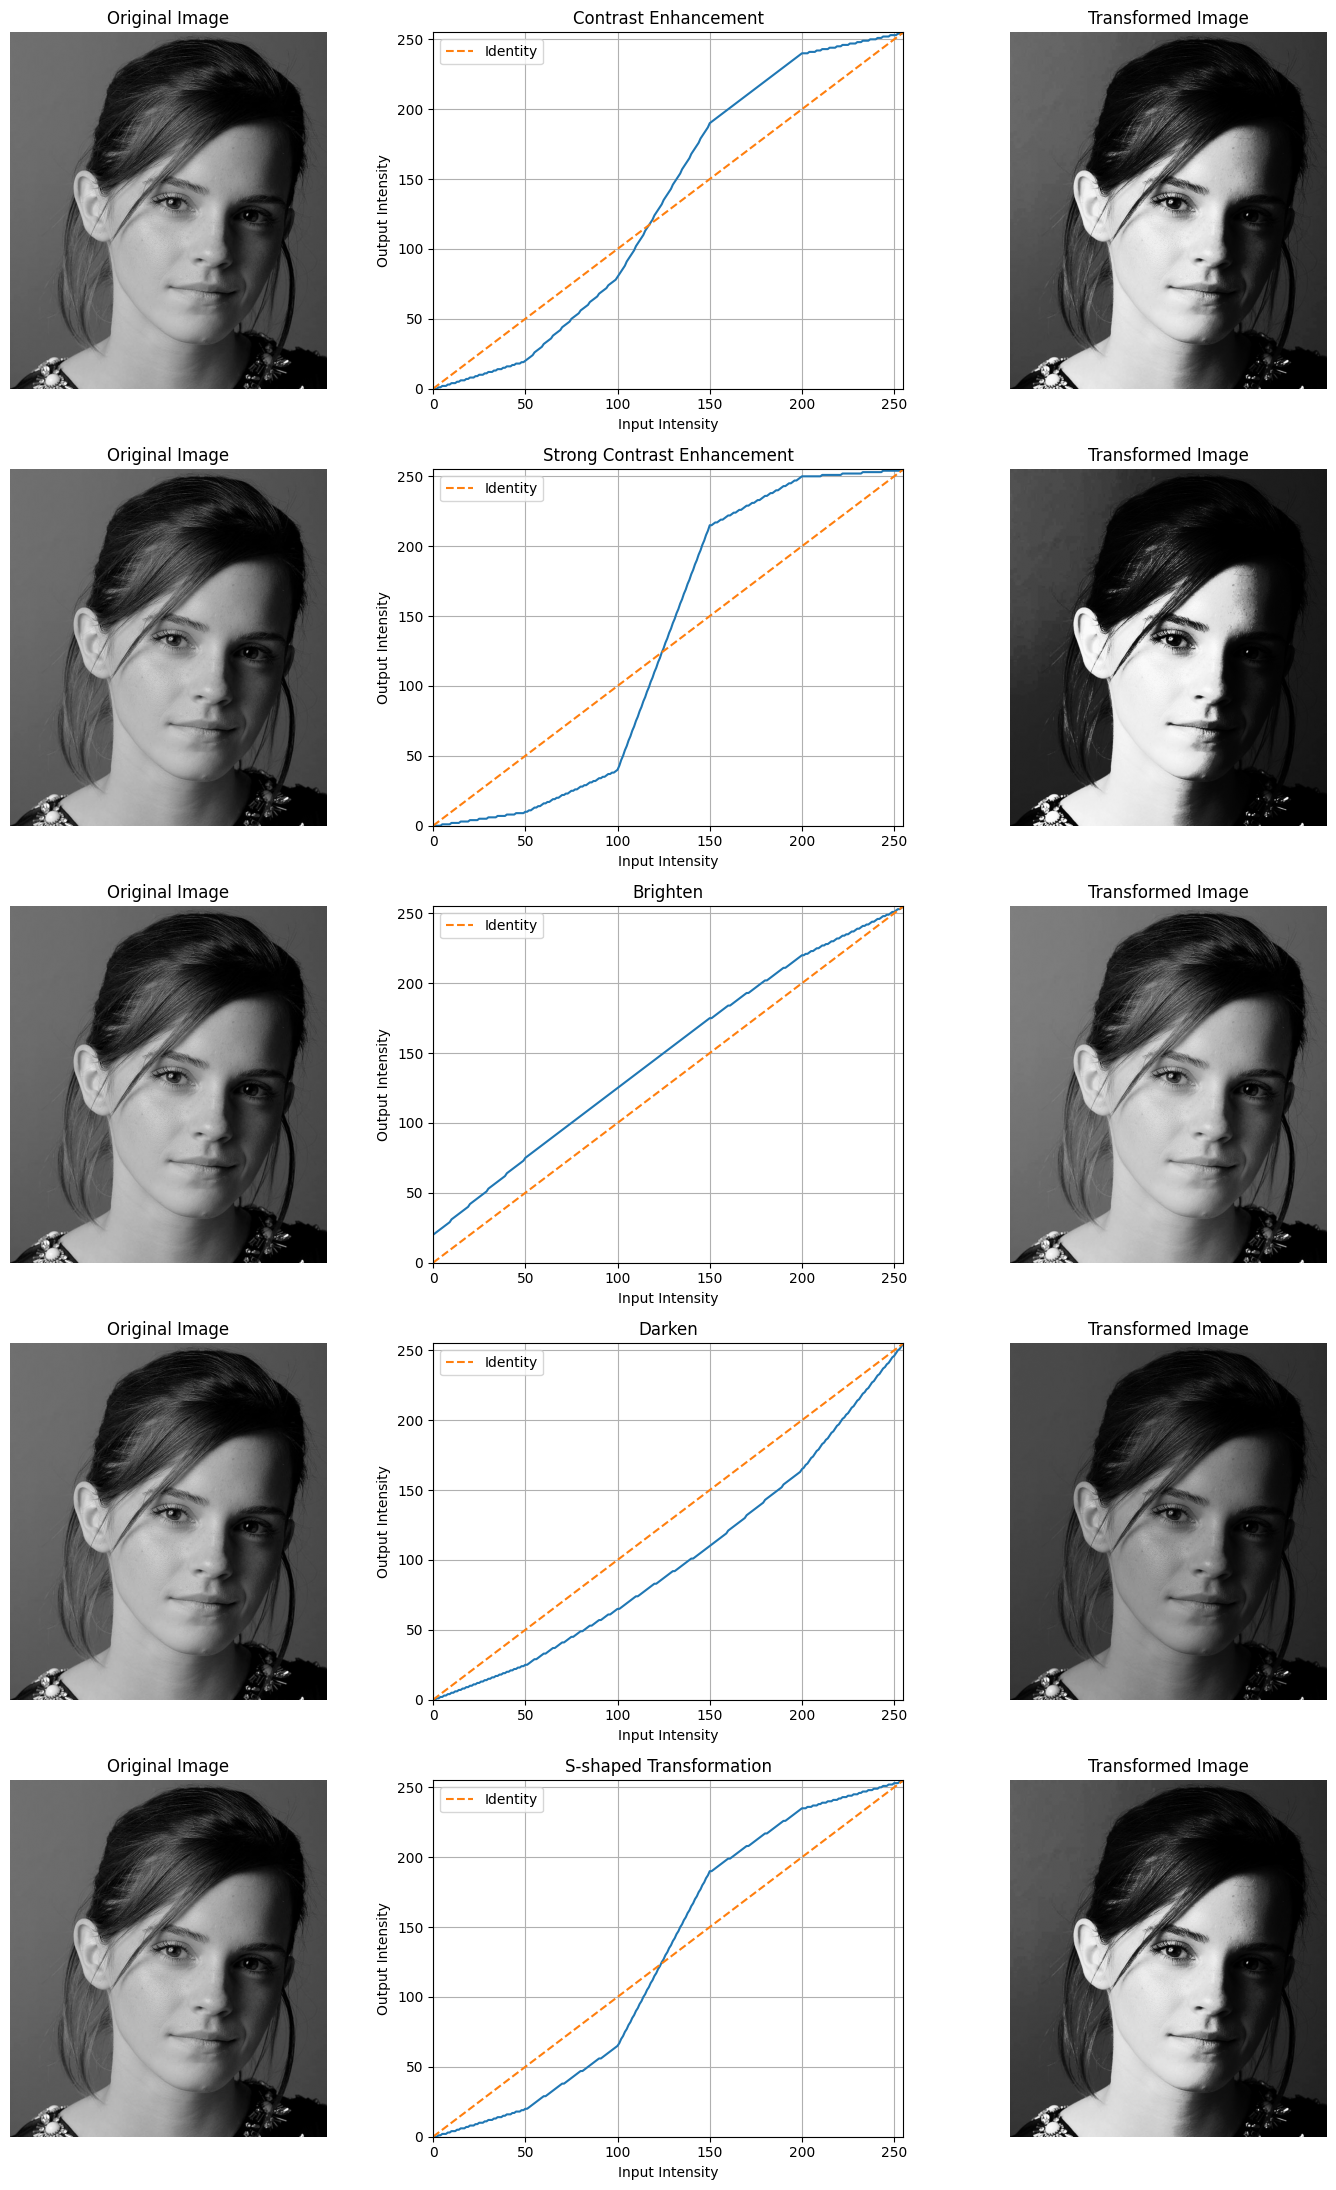

In [16]:
# Experiment with different breakpoints
# Contrast Enhancement - increase contrast in middle/high intensity range
breakpoints1=np.array([(0,0),(50,20),(100,80),(150,190),(200,240),(255,255)])

# Strong Contrast Enhancement - Dark pixel become dark and bright pixels become bright
breakpoints2=np.array([(0,0),(50,10),(100,40),(150,215),(200,250),(255,255)])

# Brighten the image - SHifting intensity upward
breakpoints3=np.array([(0,20),(50,75),(100,125),(150,175),(200,220),(255,255)])

# Darken the image
breakpoints4=np.array([(0,0),(50,25),(100,65),(150,110),(200,165),(255,255)])

# S-shaped transformation
breakpoints5=np.array([(0,0),(50,20),(100,65),(150,190),(200,235),(255,255)])

# Outputs
titles = [
    "Contrast Enhancement",
    "Strong Contrast Enhancement",
    "Brighten",
    "Darken",
    "S-shaped Transformation"
]

breakpoints_list = [breakpoints1, breakpoints2, breakpoints3, breakpoints4, breakpoints5]
fig, axes = plt.subplots(5, 3, figsize=(15, 22))

for i, (bp, title) in enumerate(zip(breakpoints_list, titles)):

    # Apply transformation
    transformed, transform = intensity_transform(im, bp)

    # Original image
    axes[i, 0].imshow(im, cmap='gray')
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Transformation graph
    axes[i, 1].plot(np.arange(256), transform)
    axes[i, 1].plot([0, 255], [0, 255], '--', label='Identity')

    axes[i, 1].set_title(title)
    axes[i, 1].set_xlabel("Input Intensity")
    axes[i, 1].set_ylabel("Output Intensity")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_ylim(0, 255)
    axes[i, 1].grid(True)
    axes[i, 1].legend()

    # Transformed image
    axes[i, 2].imshow(transformed, cmap='gray')
    axes[i, 2].set_title("Transformed Image")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

#### Question 2 

Minimum intensity:  0
Maximum intensity:  255


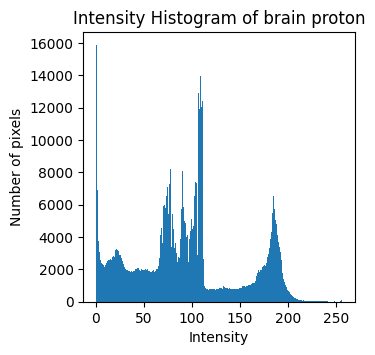

In [17]:
im2=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q2\brain proton.jpeg',cv.IMREAD_GRAYSCALE)
print("Minimum intensity: ",im.min())
print("Maximum intensity: ",im.max())

# Histogram
plt.figure(figsize=(3.5,3.5))
plt.hist(im.ravel(), bins=256, range=(0,256))
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Intensity Histogram of brain proton")
plt.show()

White matter - 170-190 <br>
Gray matter - 70-120

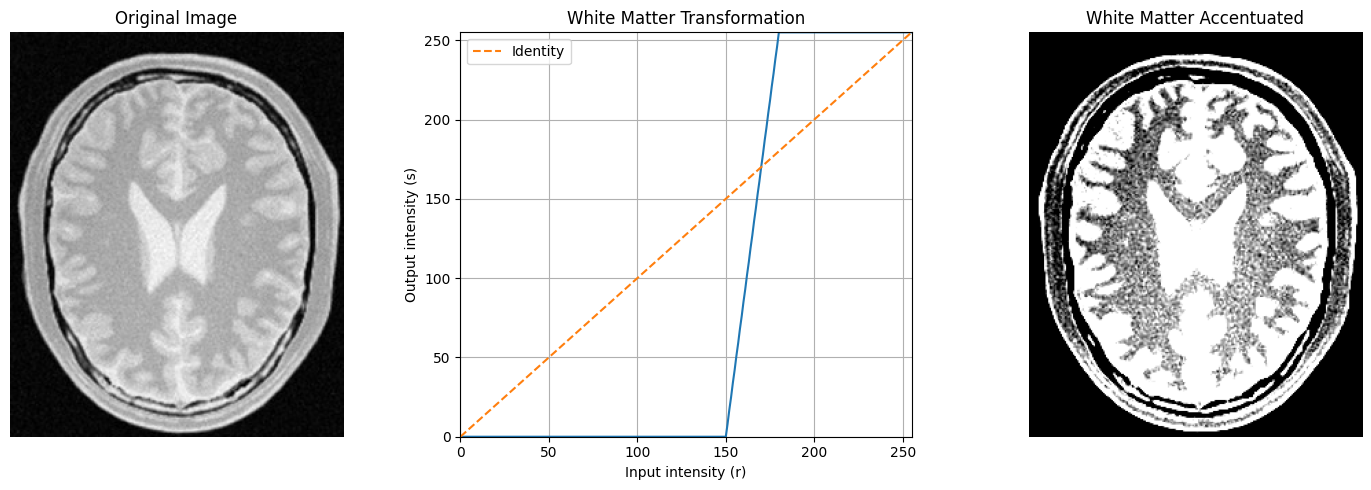

In [91]:
wm_breakpoints=[(0,0),(150,0),(180,255),(255,255)]
wm_image,wm_transform=intensity_transform(im2, wm_breakpoints)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(im2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Transformation graph
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), wm_transform)
plt.plot([0, 255], [0, 255], "--", label="Identity")
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("White Matter Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.legend()

# Output
plt.subplot(1, 3, 3)
plt.imshow(wm_image, cmap="gray")
plt.title("White Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()


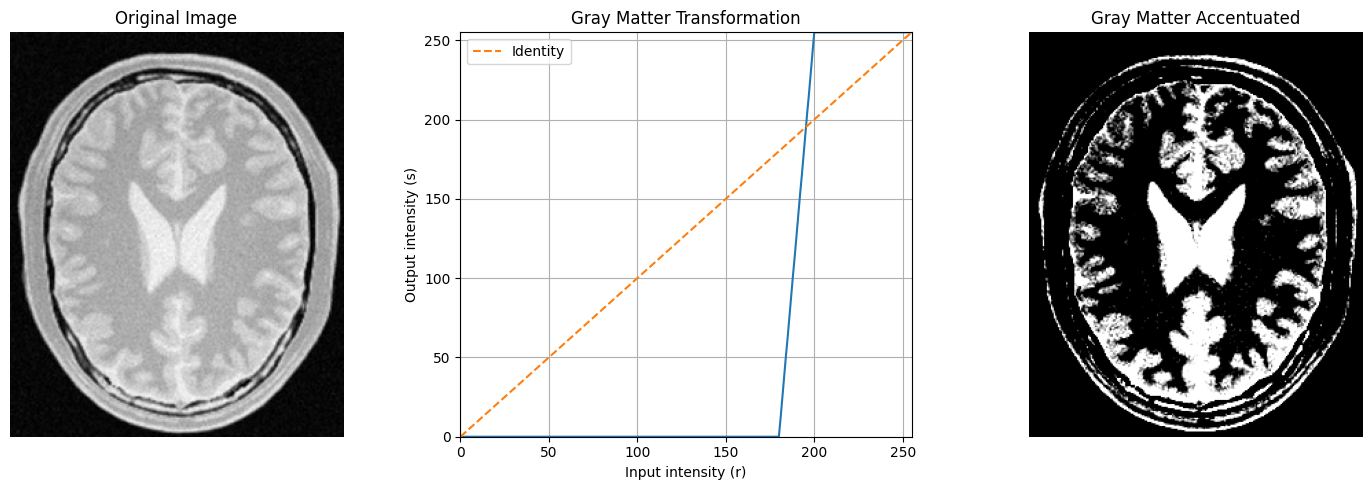

In [73]:
gm_breakpoints=[(0,0),(180,0),(200,255),(255,255)]
gm_image,gm_transform=intensity_transform(im2, gm_breakpoints)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(im2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Transformation graph
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), gm_transform)
plt.plot([0, 255], [0, 255], "--", label="Identity")
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Gray Matter Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.legend()

# Output
plt.subplot(1, 3, 3)
plt.imshow(gm_image, cmap="gray")
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()


#### Question 3 - Apply Gamma Correction

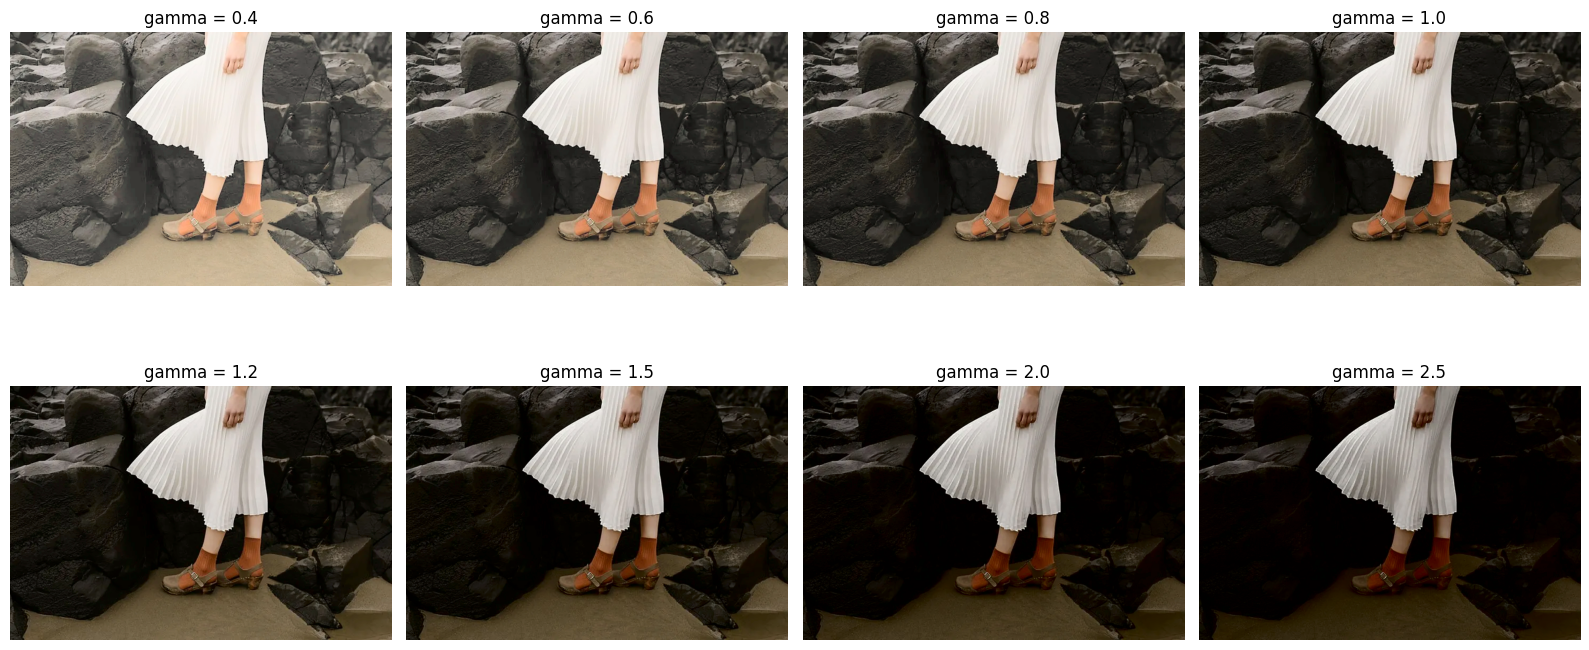

In [85]:
im3 = cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q3\img3.webp')

# convert BGR to Lab
lab=cv.cvtColor(im3,cv.COLOR_BGR2LAB)

# L channel
L=lab[:,:,0]

# separate L*, a*, b*
L,a,b = cv.split(lab)

gamma_values=[0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]

plt.figure(figsize=(16,8))

for i, gamma in enumerate(gamma_values):
    # Normalize and gamma correction
    L_norm=L/255.0
    L_gamma_corrected=np.power(L_norm,gamma)
    L_gamma_corrected=np.uint8(L_gamma_corrected*255)

    # combine L* with a* and b*
    corrected_lab=cv.merge([L_gamma_corrected,a,b])

    corrected_bgr=cv.cvtColor(corrected_lab,cv.COLOR_LAB2BGR)
    corrected_rgb=cv.cvtColor(corrected_bgr,cv.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(corrected_rgb,cmap='gray')
    plt.title(f"gamma = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()



Plotting Histogram

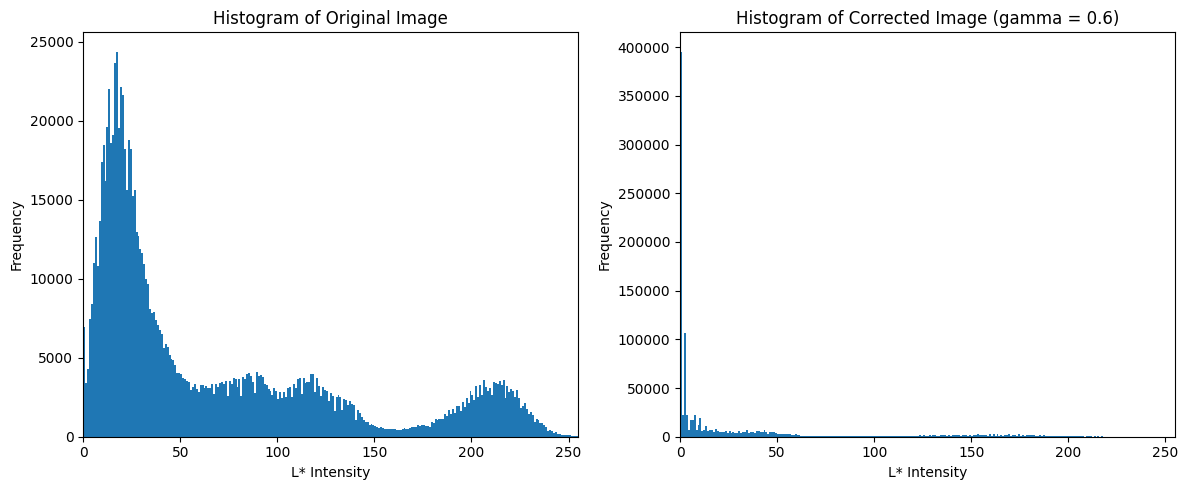

In [89]:
gamma=0.6

# Plot histograms
plt.figure(figsize=(12, 5))

# Original L* histogram
plt.subplot(1, 2, 1)
plt.hist(im3.ravel(), bins=256, range=[0, 256])
plt.title('Histogram of Original Image')
plt.xlabel('L* Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 255])

# Corrected L* histogram
plt.subplot(1, 2, 2)
plt.hist(corrected_rgb.ravel(), bins=256, range=[0, 256])
plt.title(f'Histogram of Corrected Image (gamma = {gamma})')
plt.xlabel('L* Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

#### Question 4

In [92]:
im4=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q4\spiderman.png')

# Convert BGR to HSV
hsv=cv.cvtColor(im4, cv.COLOR_BGR2HSV)
# Split into HSV
H,S,V=cv.split(hsv)

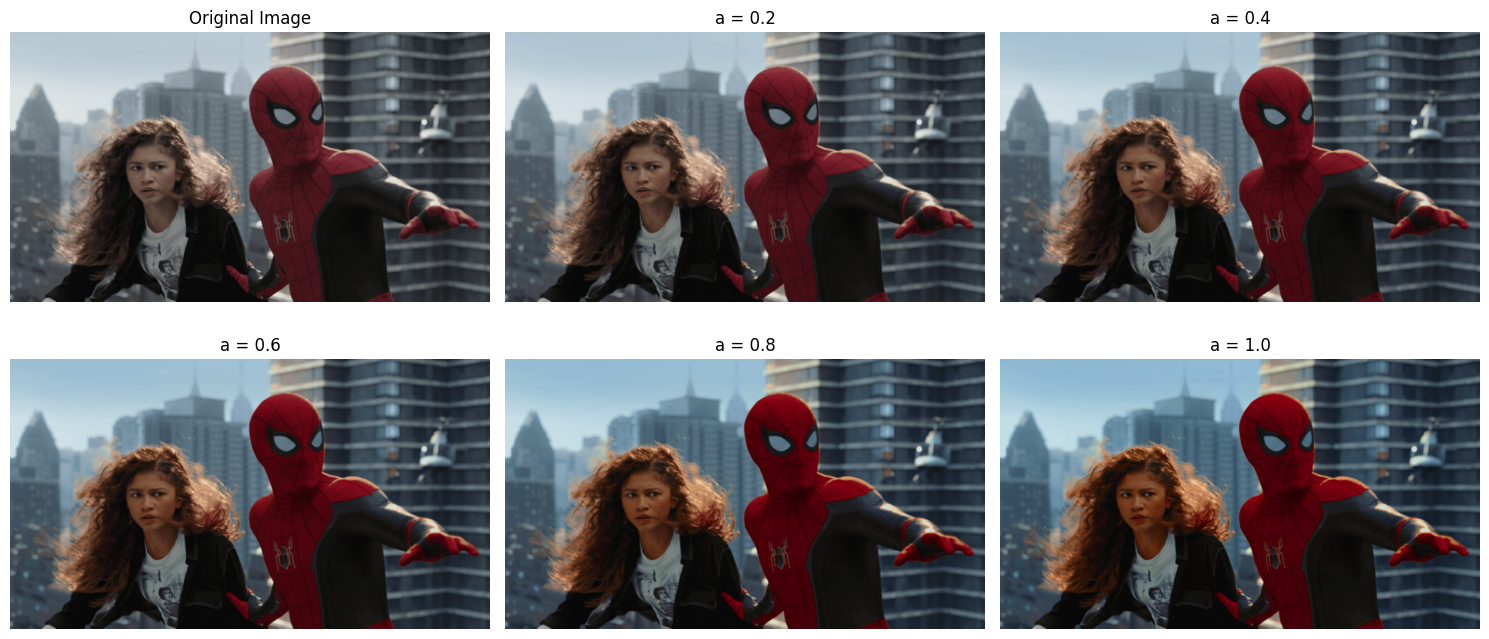

In [100]:
sigma=70

def vibrance_transform(S,a,sigma=70):
    S_float=S.astype(np.float32)
    S_new=S_float+(a*128*np.exp(-((S_float-128)**2)/(2*sigma**2)))
    S_new=np.clip(S_new,0,255)

    return S_new.astype(np.uint8)


a_values=[0.2,0.4,0.6,0.8,1.0]
enhanced_images=[]

for a in a_values:
    #Transform Saturation
    S_new=vibrance_transform(S,a,sigma)
    # Recombine H, modified H and s
    hsv_new=cv.merge([H,S_new,V])
    #HSV->BGR
    enhanced=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)
    enhanced_images.append(enhanced)

# Display
plt.figure(figsize=(15,7))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(cv.cvtColor(im4, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')


# Different values of a
for i, a in enumerate(a_values):

    plt.subplot(2, 3, i + 2)

    plt.imshow(
        cv.cvtColor(enhanced_images[i], cv.COLOR_BGR2RGB)
    )

    plt.title(f'a = {a}')
    plt.axis('off')

plt.tight_layout()
plt.show()


a=0.8

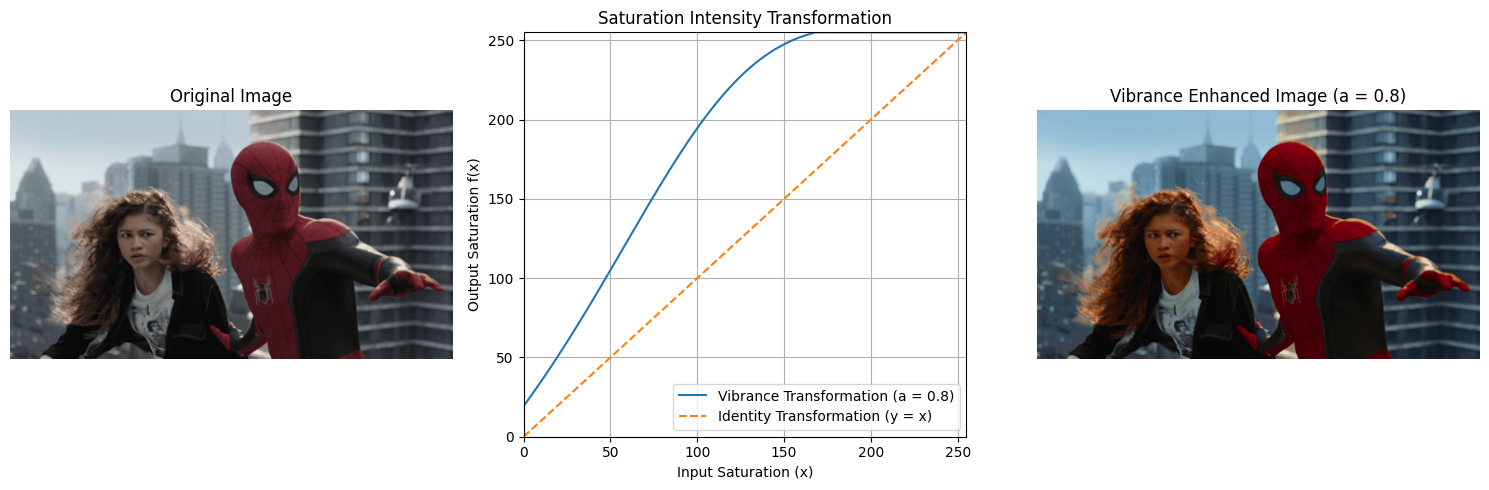

In [105]:
a=0.8

hsv_enhanced = cv.merge([H, S_new, V])
enhanced = cv.cvtColor(hsv_enhanced,cv.COLOR_HSV2BGR)

plt.figure(figsize=(15, 5))

#original image
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(im4, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Transformation curve
plt.subplot(1, 3, 2)
x=np.arange(256,dtype=np.float32)
f_x=x+(a*128*np.exp(-((x-128)**2)/(2*sigma**2)))
f_x=np.clip(f_x,0,255)

plt.plot(x,f_x,label=f'Vibrance Transformation (a = {a})')

# Identity line y = x
plt.plot(x,x,'--',label='Identity Transformation (y = x)')

plt.xlabel('Input Saturation (x)')
plt.ylabel('Output Saturation f(x)')

plt.title('Saturation Intensity Transformation')

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid()
plt.legend()

#Enhanced Image
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB))
plt.title(f'Vibrance Enhanced Image (a = {a})')
plt.axis('off')


plt.tight_layout()
plt.show()

Question 5 - Histogram Equalization Function

In [109]:
def histogram_equalization(im):
    L=256
    M,N=im.shape
    hist=np.bincount(im.ravel(),minlength=L)
    cdf=hist.cumsum()
    t=((L-1)/(M*N))*cdf

    # convert to integer
    t=np.round(t).astype(np.uint8)
    g=t[im]

    return g, hist, t

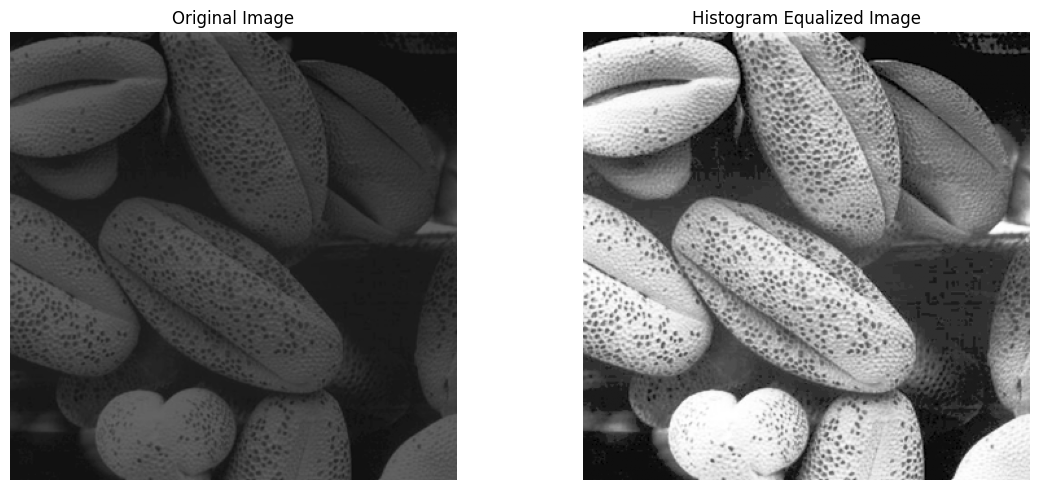

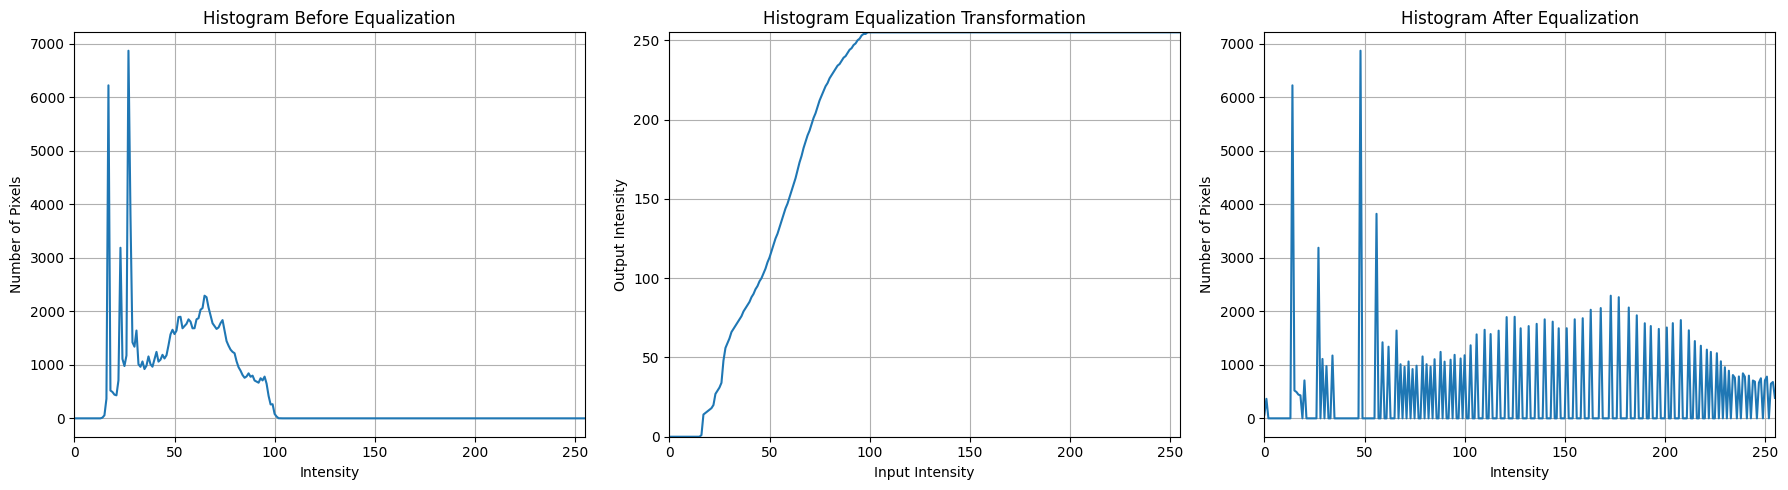

In [111]:
im_orig=im5=cv.imread(r'c:\Users\shala\OneDrive\Pictures\Screenshots 1\Screenshot 2026-09-12 223154.png')
im5=cv.imread(r'c:\Users\shala\OneDrive\Pictures\Screenshots 1\Screenshot 2026-09-12 223154.png',cv.IMREAD_GRAYSCALE)

equalized, hist_before, transform = histogram_equalization(im5)
hist_after = np.bincount(equalized.ravel(),minlength=256)

# Display image
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(im_orig, cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1, 2, 2)

plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

# Display histogram
plt.figure(figsize=(18, 5))

# Histogram before
plt.subplot(1, 3, 1)
plt.plot(hist_before)
plt.title('Histogram Before Equalization')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.xlim(0, 255)
plt.grid()

# Transformation
plt.subplot(1, 3, 2)

r = np.arange(256)
plt.plot(r, transform)

plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Histogram Equalization Transformation')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

# Histogram after
plt.subplot(1, 3, 3)
plt.plot(hist_after)
plt.title('Histogram After Equalization')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.xlim(0, 255)
plt.grid()

plt.tight_layout()
plt.show()

#### Question 6

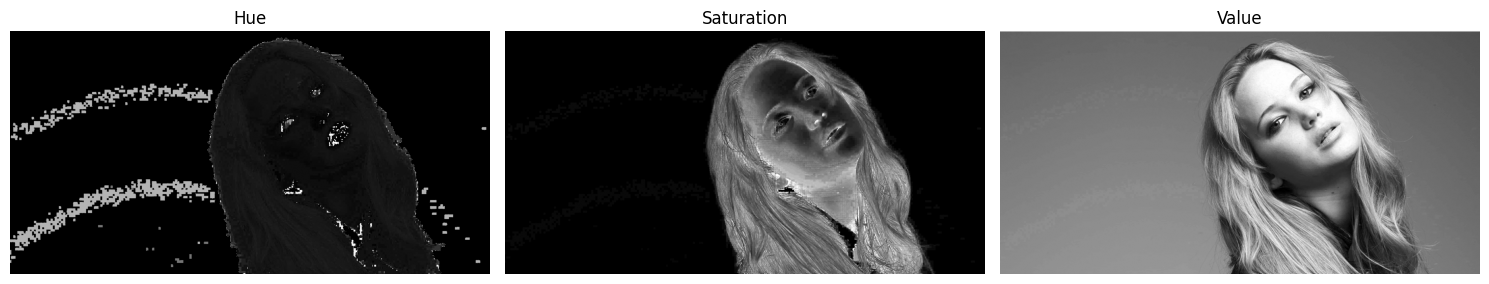

In [ ]:
im6=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q6\Q6.png')

#convert BGR to HSV
hsv=cv.cvtColor(im6,cv.COLOR_BGR2HSV)
#Split
# H - Type of Colour  S - Colour Intensity   V - Brightness
H,S,V=cv.split(hsv)

# Display planes in gray scale
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title('Hue')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title('Saturation')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray')
plt.title('Value')
plt.axis('off')

plt.tight_layout()
plt.show()

0
255


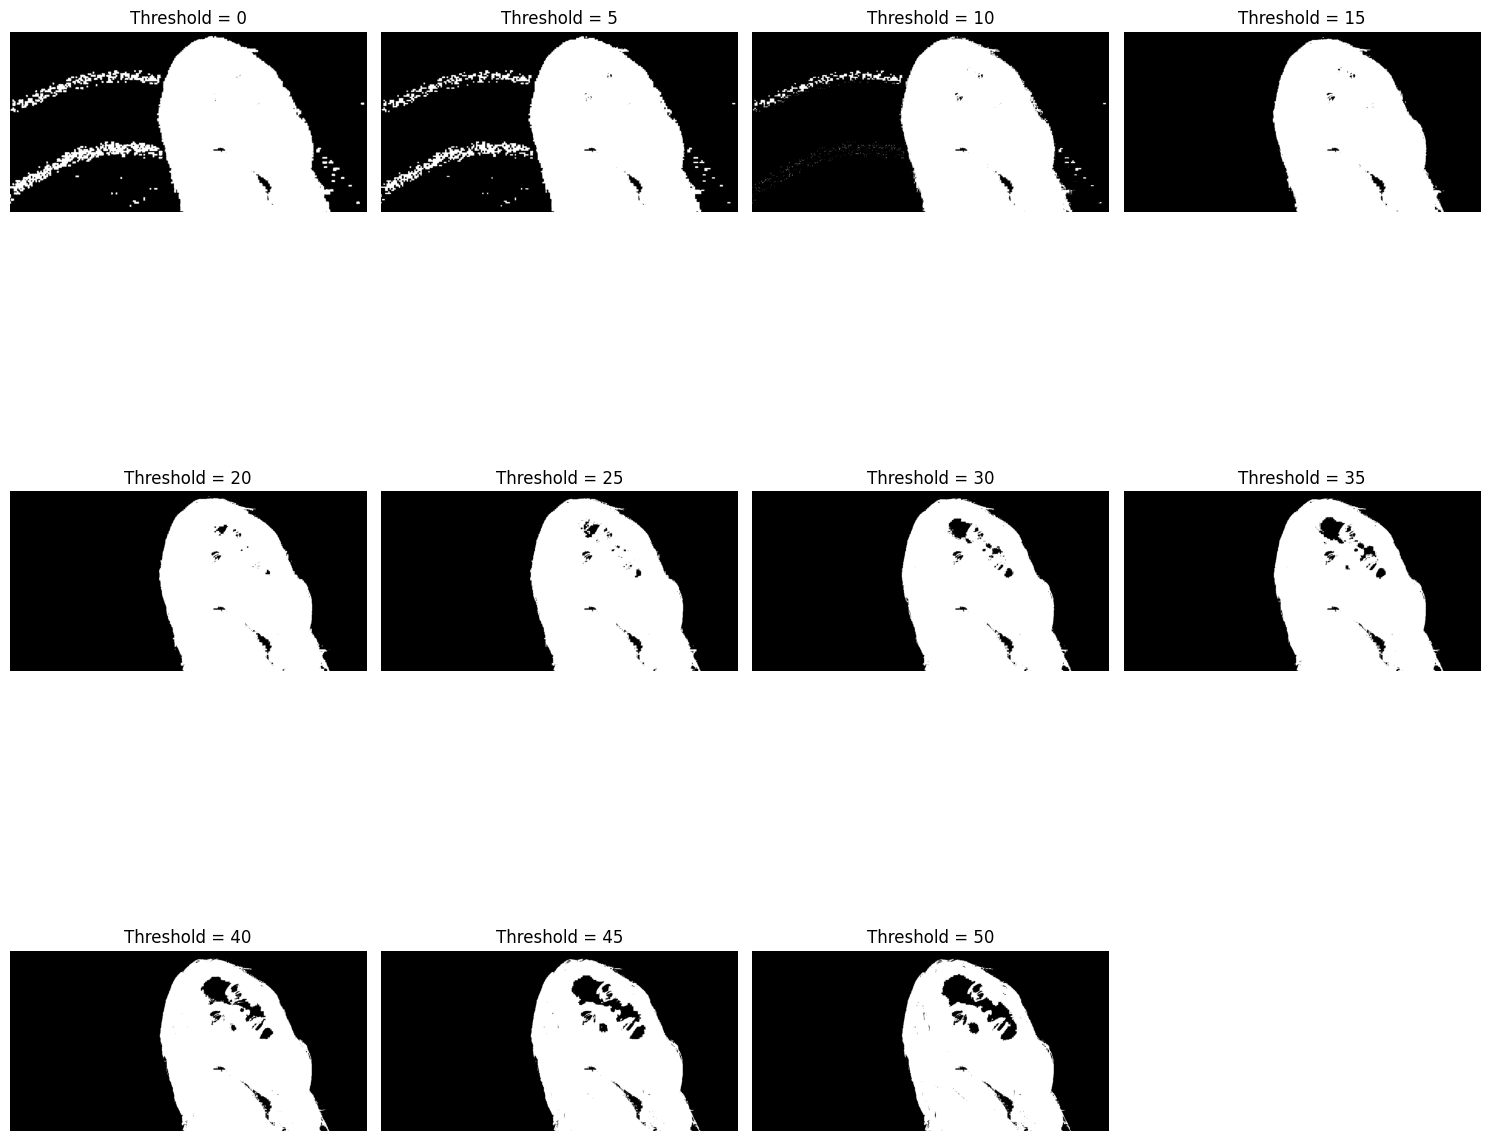

In [124]:
# Part b
print(S.min())
print(S.max())

thresholds=range(0,51,5)
plt.figure(figsize=(15,15))
for i,threshold in enumerate(thresholds):
    _, mask=cv.threshold(S,threshold,255,cv.THRESH_BINARY)

    plt.subplot(3, 4, i + 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Threshold = {threshold}')
    plt.axis('off')

plt.tight_layout()
plt.show()


Threshold = 15

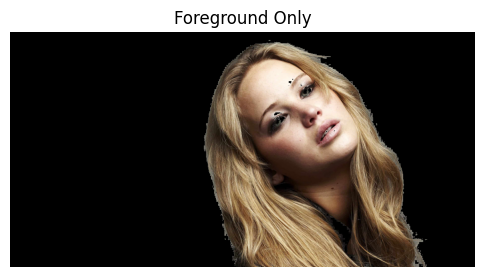

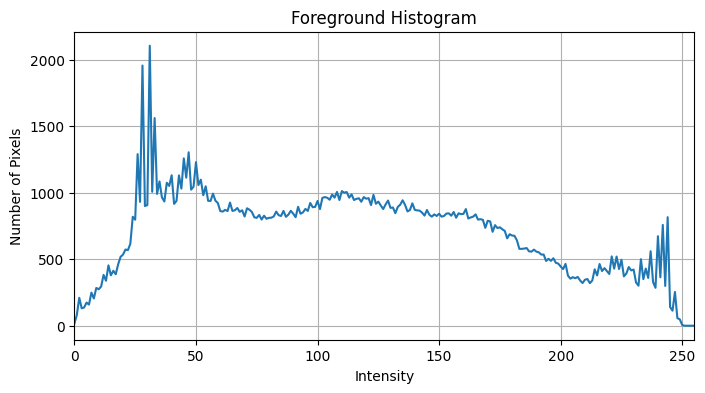

In [135]:
# Part c
threshold=15
_, f_mask=cv.threshold(S,threshold,255,cv.THRESH_BINARY)
foreground=cv.bitwise_and(im6,im6,mask=f_mask)

plt.figure(figsize=(6, 5))

plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Foreground Only')
plt.axis('off')

plt.show()

#compute histogram
gray=cv.cvtColor(im6,cv.COLOR_BGR2GRAY)
foreground_gray=cv.bitwise_and(gray,gray,mask=f_mask)
foreground_pixels = foreground_gray[f_mask == 255]
hist = np.bincount(foreground_pixels,minlength=256)

plt.figure(figsize=(8, 4))
plt.plot(hist)
plt.title('Foreground Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.xlim(0, 255)
plt.grid()
plt.show()


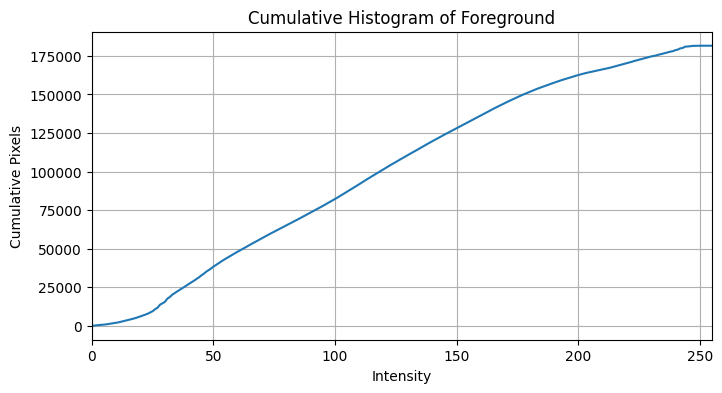

In [136]:
# Part d
cdf=np.cumsum(hist)

plt.figure(figsize=(8, 4))
plt.plot(cdf)
plt.title('Cumulative Histogram of Foreground')
plt.xlabel('Intensity')
plt.ylabel('Cumulative Pixels')
plt.xlim(0, 255)
plt.grid()
plt.show()

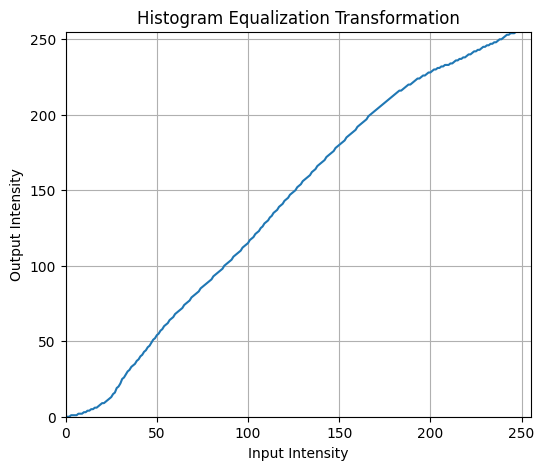

In [137]:
# Part e
L = 256
no_f_pixels=np.sum(f_mask==255)
t=((L-1)/no_f_pixels)*cdf
t=np.round(t).astype(np.uint8)

equalized_foreground = np.zeros_like(gray)
equalized_foreground[f_mask == 255] = t[foreground_gray[f_mask == 255]]

plt.figure(figsize=(6, 5))
plt.plot(np.arange(256), t)
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Histogram Equalization Transformation')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.show()

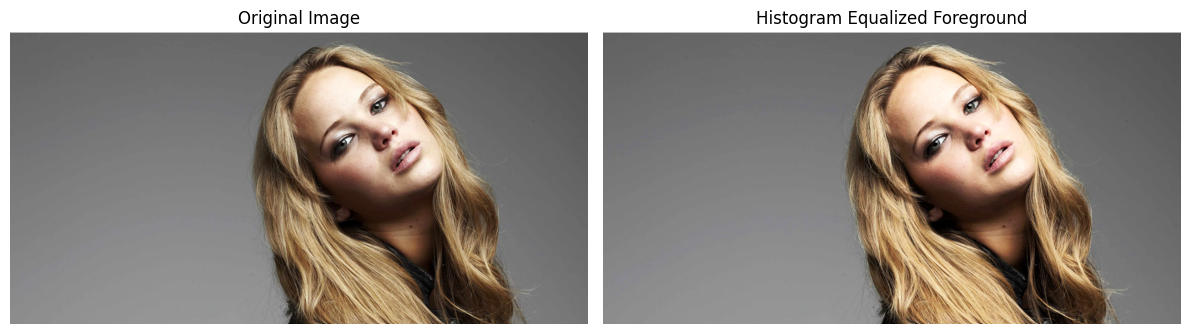

In [145]:
# part f
# Convert original image to HSV
hsv_result = cv.cvtColor(im6, cv.COLOR_BGR2HSV)

# Get the Value channel
V_result = hsv_result[:, :, 2].copy()

# Apply histogram equalization only to foreground
V_result[f_mask == 255] = t[V[f_mask == 255]]

# Put the modified V channel back
hsv_result[:, :, 2] = V_result

# Convert HSV back to BGR
result_colour = cv.cvtColor(hsv_result, cv.COLOR_HSV2RGB)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(im6, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_colour)
plt.title('Histogram Equalized Foreground')
plt.axis('off')

plt.tight_layout()
plt.show()